In [ ]:
# test_point_astar.ipynb 交互式实现

import os
import numpy as np
from PIL import Image
import gymnasium as gym
import base64
import io
import json
import heapq
import time
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import ipywidgets as widgets
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
from tool_server.tool_workers.tool_manager.base_manager import ToolManager
from tool_server.utils.utils import pil_to_base64, base64_to_pil



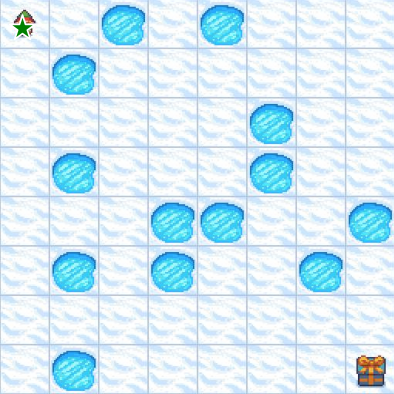

In [ ]:
# 初始化工具管理器
tool_manager = ToolManager()
env = gym.make('FrozenLake-v1', desc=generate_random_map(8), render_mode="rgb_array", is_slippery=False)
env.reset()
env_image = Image.fromarray(env.render())
image_base64 = pil_to_base64(env_image)
desc = "Elf"

params = {
    "image": image_base64,
    "description": desc,
}
res = tool_manager.call_tool("Point",params=params)
res.pop("raw_response",None)
res.pop("tool_reward",None)
edited_image = res.pop("edited_image", None)
edited_image = base64_to_pil(edited_image)
edited_image

In [13]:
res

{'tool_response_from': 'Point',
 'status': 'success',
 'points': [{'x': 28, 'y': 36}],
 'image_dimensions_pixels': {'width': 512, 'height': 512},
 'error_code': 0}

2025-07-21 11:12:42 | INFO | base_offline_worker | Initialized offline worker: AStarWithPixelCoordinate
2025-07-21 11:12:42 | INFO | base_offline_worker | Initialized offline worker: Draw2DPath
2025-07-21 11:12:42 | INFO | base_offline_worker | Initialized offline worker: TurnCoordinateIntoTextMap
2025-07-21 11:12:42 | INFO | tool_manager | Offline Tools: ['AStarWithPixelCoordinate', 'Draw2DPath', 'TurnCoordinateIntoTextMap']
2025-07-21 11:12:42 | INFO | tool_manager | controller_addr is None, using default from controller_addr_location
2025-07-21 11:12:42 | INFO | tool_manager | Online Tools: ['HighlightBox', 'GroundingDINO', 'MaskBox', 'GetBarInfo', 'GetSubplotInfo', 'DrawShape', 'OCR', 'Crop', 'Point', 'SegmentRegionAroundPoint', 'DrawLine']
2025-07-21 11:12:42 | INFO | tool_manager | All required online tools are prepared successfully
2025-07-21 11:12:42 | INFO | tool_manager | ToolManager is initialized.
2025-07-21 11:12:42 | INFO | stdout | available_tools ['HighlightBox', 'Groun

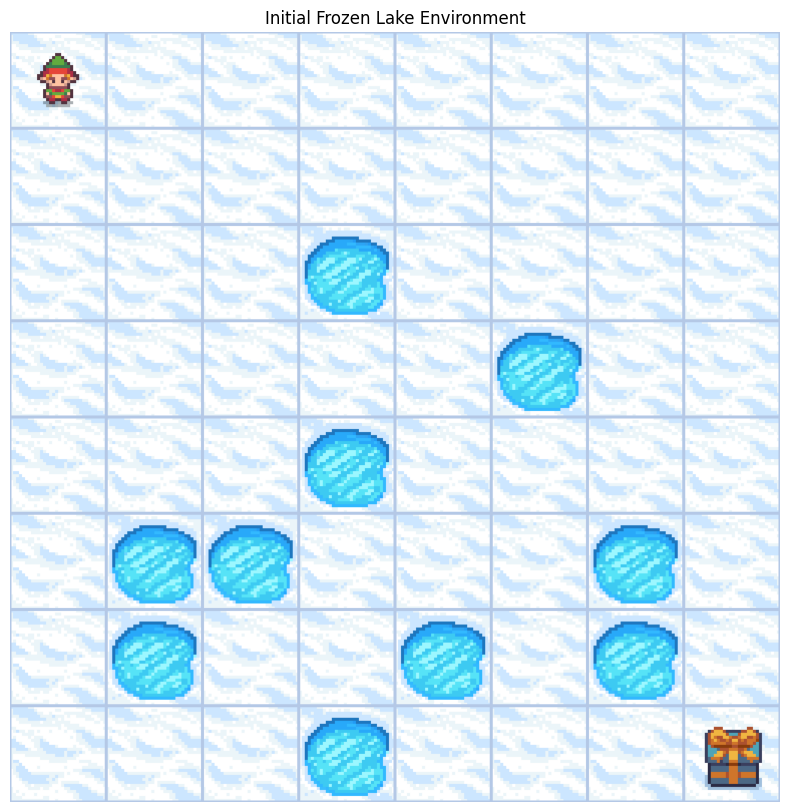

2025-07-21 11:12:44 | INFO | stdout | 
2025-07-21 11:12:44 | INFO | stdout | 自定义坐标测试:


<function __main__.cleanup()>

2025-07-21 11:12:46 | INFO | stdout | 启动完整工作流...
2025-07-21 11:12:46 | INFO | stdout | 
2025-07-21 11:12:46 | INFO | stdout | 步骤1: 定位起点(Elf)
2025-07-21 11:12:48 | INFO | stdout | 找到坐标: [[31.744, 33.28]]


2025-07-21 11:12:48 | INFO | stdout | 
2025-07-21 11:12:48 | INFO | stdout | 步骤2: 定位终点(Goal)
2025-07-21 11:12:50 | INFO | stdout | 找到坐标: [[482.816, 481.28]]


2025-07-21 11:12:51 | INFO | stdout | 
2025-07-21 11:12:51 | INFO | stdout | 步骤3: 识别障碍物(Holes)
2025-07-21 11:12:56 | INFO | stdout | 找到坐标: [[94.72, 417.28], [97.28, 352.76800000000003], [161.28, 354.816], [222.72, 161.28], [225.28, 286.72], [225.28, 476.16], [289.28, 417.28], [353.28, 222.72], [412.16, 417.28], [414.72, 354.816]]


2025-07-21 11:12:56 | INFO | stdout | 最终使用的障碍物坐标: [[94.72, 417.28], [97.28, 352.76800000000003], [161.28, 354.816], [222.72, 161.28], [225.28, 286.72], [225.28, 476.16], [289.28, 417.28], [353.28, 222.72], [412.16, 417.28], [414.72, 354.816]]
2025-07-21 11:12:56 | INFO | stdout | 
2025-07-21 11:12:56 | INFO | stdout | 步骤4: 生成文本地图
2025-07-21 11:12:56 | INFO | stdout | 生成的文本地图:
2025-07-21 11:12:56 | INFO | stdout | | | Col 1 | Col 2 | Col 3 | Col 4 | Col 5 | Col 6 | Col 7 | Col 8 |
2025-07-21 11:12:56 | INFO | stdout | | Row 1 | @ | _ | _ | _ | _ | _ | _ | _ |
2025-07-21 11:12:56 | INFO | stdout | | Row 2 | _ | _ | _ | _ | _ | _ | _ | _ |
2025-07-21 11:12:56 | INFO | stdout | | Row 3 | _ | _ | _ | # | _ | _ | _ | _ |
2025-07-21 11:12:56 | INFO | stdout | | Row 4 | _ | _ | _ | _ | _ | # | _ | _ |
2025-07-21 11:12:56 | INFO | stdout | | Row 5 | _ | _ | _ | # | _ | _ | _ | _ |
2025-07-21 11:12:56 | INFO | stdout | | Row 6 | _ | # | # | _ | _ | _ | # | _ |
2025-07-21 11:12:56 | INFO | stdout

Output()

In [1]:
# test_point_astar.ipynb 交互式实现

import os
import numpy as np
from PIL import Image
import gymnasium as gym
import base64
import io
import json
import heapq
import time
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import ipywidgets as widgets

from tool_server.tool_workers.tool_manager.base_manager import ToolManager

# 初始化工具管理器
tool_manager = ToolManager()

# 检查需要使用的工具是否可用
all_tools = tool_manager.available_tools
print("可用工具:")
for tool in all_tools:
    print(f"- {tool}")

# 准备FrozenLake环境
def create_frozen_lake(custom_map=None, size=8):
    if custom_map:
        desc = custom_map
    else:
        # 默认地图
        desc = [
            "SFFFFFFF",
            "FFFFFFFF",
            "FFFHFFFF",
            "FFFFFHFF",
            "FFFHFFFF",
            "FHHFFFHF",
            "FHFFHFHF",
            "FFFHFFFG"
        ]
    
    env = gym.make('FrozenLake-v1', desc=desc, render_mode="rgb_array", is_slippery=False)
    env.reset()
    env_image = Image.fromarray(env.render())
    
    # 保存临时文件
    temp_image_path = "temp_frozen_lake.png"
    env_image.save(temp_image_path)
    
    # 将图片转换为base64
    with open(temp_image_path, "rb") as image_file:
        image_base64 = base64.b64encode(image_file.read()).decode('utf-8')
    
    return {
        'env': env,
        'image': env_image,
        'image_path': temp_image_path,
        'image_base64': image_base64,
        'desc': desc,
        'cell_size': 64
    }

# 创建环境
lake_env = create_frozen_lake()

# 显示初始环境
plt.figure(figsize=(10, 10))
plt.imshow(lake_env['image'])
plt.axis('off')
plt.title('Initial Frozen Lake Environment')
plt.show()

# 工具1: 使用Point模型定位
def locate_point_with_description(image_base64, description):
    """使用Point模型定位描述的对象"""
    if "Point" not in tool_manager.available_tools:
        print("警告: Point工具不可用")
        return None
    
    params = {
        "image": image_base64,
        "description": description
    }
    
    result = tool_manager.call_tool("Point", params)
    
    if result['status'] == "success" and len(result.get('points', [])) > 0:
        point = [[item['x'], item['y']] for item in result['points']]
        print(f"找到坐标: {point}")
        
        # 显示带标记的图像
        if 'edited_image' in result:
            marked_image = base64_to_image(result['edited_image'])
            plt.figure(figsize=(10, 10))
            plt.imshow(marked_image)
            plt.axis('off')
            plt.title(f'Located: {description}')
            plt.show()
        
        return point
    else:
        print(f"未能定位: {description} - {result.get('message', '未知错误')}")
        return None

# 辅助函数: Base64和图像转换
def image_to_base64(image_path):
    """将图片转换为Base64字符串"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def base64_to_image(base64_string):
    """将Base64字符串转换为PIL图像"""
    image_data = base64.b64decode(base64_string)
    return Image.open(io.BytesIO(image_data))

# 手动提取已知障碍物坐标
def extract_known_obstacles(desc, cell_size=64):
    """从描述中提取障碍物坐标"""
    obstacles = []
    
    for i, row in enumerate(desc):
        for j, cell in enumerate(row):
            cell_str = cell.decode('utf-8') if isinstance(cell, bytes) else cell
            if cell_str == 'H':
                pixel_x = j * cell_size + cell_size/2
                pixel_y = i * cell_size + cell_size/2
                obstacles.append([pixel_x, pixel_y])
    
    return obstacles

# 交互式点定位界面
def create_point_locator_interface():
    description_input = widgets.Text(
        value='the starting position (S/Elf) in the frozen lake',
        description='描述:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='80%')
    )
    
    result_output = widgets.Output()
    
    def on_locate_button_click(b):
        with result_output:
            result_output.clear_output()
            description = description_input.value
            print(f"正在定位: {description}")
            point = locate_point_with_description(lake_env['image_base64'], description)
            if point:
                print(f"成功定位! 坐标: {point}")
    
    locate_button = widgets.Button(
        description='定位',
        button_style='primary',
        tooltip='使用Point模型定位描述的对象'
    )
    
    locate_button.on_click(on_locate_button_click)
    
    return widgets.VBox([
        widgets.HBox([description_input, locate_button]),
        result_output
    ])

# 创建并显示交互式界面
point_locator = create_point_locator_interface()
display(point_locator)

# 完整工作流
def run_full_workflow():
    # 输出区域
    output = widgets.Output()
    
    with output:
        print("启动完整工作流...")
        
        # 步骤1: 定位起点
        print("\n步骤1: 定位起点(Elf)")
        start_point = locate_point_with_description(lake_env['image_base64'], "the starting position (S/Elf) in the frozen lake")
        start_point = start_point[0] if start_point else None
        if not start_point:
            print("使用默认起点坐标")
            start_point = [32, 32]  # 默认使用第一个格子的中心点
        
        # 步骤2: 定位终点
        print("\n步骤2: 定位终点(Goal)")
        goal_point = locate_point_with_description(lake_env['image_base64'], "the goal position (G/Gift) in the frozen lake")
        goal_point = goal_point[0] if goal_point else None
        if not goal_point:
            print("使用默认终点坐标")
            cell_size = lake_env['cell_size']
            size = len(lake_env['desc'])
            goal_point = [(size-1) * cell_size + cell_size/2, (size-1) * cell_size + cell_size/2]  # 默认使用右下角的格子
        
        # 步骤3: 识别障碍物
        print("\n步骤3: 识别障碍物(Holes)")
        # 使用Point识别一个障碍物
        hole_point = locate_point_with_description(lake_env['image_base64'], "Ice Hole")
        obstacles = hole_point
        
        print(f"最终使用的障碍物坐标: {obstacles}")
        
        # 步骤4: 生成文本地图
        print("\n步骤4: 生成文本地图")
        map_params = {
            "start": start_point,
            "goal": goal_point,
            "obstacles": obstacles,
            "cell_size": lake_env['cell_size']
        }
        
        map_result = tool_manager.call_tool("TurnCoordinateIntoTextMap", map_params)
        if map_result['status'] == "success":
            print("生成的文本地图:")
            print(map_result['text_map'])
        
        # 步骤5: 使用A*寻找路径
        print("\n步骤5: 使用A*寻找路径")
        astar_params = {
            "start": start_point,
            "goal": goal_point,
            "obstacles": obstacles
        }
        
        astar_result = tool_manager.call_tool("AStarWithPixelCoordinate", astar_params)
        if astar_result['status'] == "success":
            path = astar_result['path']
            print(f"找到路径: {path}")
            
            # 步骤6: 绘制路径
            print("\n步骤6: 绘制路径")
            draw_params = {
                "image": lake_env['image_path'],
                "start_point": start_point,
                "directions": path,
                "pixel_coordinate": True,
                "step": lake_env['cell_size'],
                "line_color": "blue",
                "line_width": 5
            }
            
            draw_result = tool_manager.call_tool("Draw2DPath", draw_params)
            if draw_result['status'] == "success" and "edited_image" in draw_result:
                final_image = base64_to_image(draw_result['edited_image'])
                final_image.save("interactive_path_result.png")
                print("路径绘制结果已保存为 interactive_path_result.png")
                
                # 显示最终图像
                plt.figure(figsize=(10, 10))
                plt.imshow(final_image)
                plt.axis('off')
                plt.title('Final Path')
                plt.show()
            else:
                print(f"路径绘制失败: {draw_result.get('message', '未知错误')}")
        else:
            print(f"A*寻路失败: {astar_result.get('message', '未知错误')}")
    
    return output

# 创建运行按钮
run_button = widgets.Button(
    description='运行完整工作流',
    button_style='success',
    tooltip='运行完整的点定位与路径规划工作流'
)

workflow_output = widgets.Output()

def on_run_button_click(b):
    with workflow_output:
        workflow_output.clear_output()
        output = run_full_workflow()
        display(output)

run_button.on_click(on_run_button_click)

# 显示运行按钮和输出区域
display(widgets.VBox([run_button, workflow_output]))

# 提供自定义测试的功能
def test_specific_coordinates():
    start_x = widgets.FloatText(value=32.0, description='起点 X:', style={'description_width': 'initial'})
    start_y = widgets.FloatText(value=32.0, description='起点 Y:', style={'description_width': 'initial'})
    goal_x = widgets.FloatText(value=480.0, description='终点 X:', style={'description_width': 'initial'})
    goal_y = widgets.FloatText(value=480.0, description='终点 Y:', style={'description_width': 'initial'})
    
    output = widgets.Output()
    
    def on_test_button_click(b):
        with output:
            output.clear_output()
            start_point = [start_x.value, start_y.value]
            goal_point = [goal_x.value, goal_y.value]
            obstacles = extract_known_obstacles(lake_env['desc'], lake_env['cell_size'])
            
            print(f"使用指定坐标:\n起点: {start_point}\n终点: {goal_point}\n障碍物数量: {len(obstacles)}")
            
            # 运行A*寻路
            astar_params = {
                "start": start_point,
                "goal": goal_point,
                "obstacles": obstacles
            }
            
            astar_result = tool_manager.call_tool("AStarWithPixelCoordinate", astar_params)
            if astar_result['status'] == "success":
                path = astar_result['path']
                print(f"找到路径: {path}")
                
                # 绘制路径
                draw_params = {
                    "image": lake_env['image_path'],
                    "start_point": start_point,
                    "directions": path,
                    "pixel_coordinate": True,
                    "step": lake_env['cell_size']
                }
                
                draw_result = tool_manager.call_tool("Draw2DPath", draw_params)
                if draw_result['status'] == "success" and "edited_image" in draw_result:
                    final_image = base64_to_image(draw_result['edited_image'])
                    final_image.save("custom_path_result.png")
                    
                    plt.figure(figsize=(10, 10))
                    plt.imshow(final_image)
                    plt.axis('off')
                    plt.title('Custom Coordinates Path')
                    plt.show()
            else:
                print(f"A*寻路失败: {astar_result.get('message', '未知错误')}")
    
    test_button = widgets.Button(
        description='测试坐标',
        button_style='info',
        tooltip='使用指定坐标测试A*寻路'
    )
    
    test_button.on_click(on_test_button_click)
    
    return widgets.VBox([
        widgets.HBox([start_x, start_y]),
        widgets.HBox([goal_x, goal_y]),
        test_button,
        output
    ])

# 显示自定义坐标测试界面
print("\n自定义坐标测试:")
custom_test = test_specific_coordinates()
display(custom_test)

# 清理函数
def cleanup():
    try:
        lake_env['env'].close()
        if os.path.exists(lake_env['image_path']):
            os.remove(lake_env['image_path'])
        for f in ["start_point.png", "goal_point.png", "holes_points.png", 
                  "point_astar_path_result.png", "interactive_path_result.png", 
                  "custom_path_result.png"]:
            if os.path.exists(f):
                os.remove(f)
    except Exception as e:
        print(f"清理过程中出错: {e}")

# 注册清理函数，在notebook关闭时执行
import atexit
atexit.register(cleanup)